In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import os
import seaborn as sns

In [2]:
def calculate_clm_rootfr(z, beta):
    nlevsoi = len(z)
    rootfr = np.zeros(len(z))
    for i in np.arange(1, nlevsoi):
        rootfr[i] = beta ** (z[i-1]*100) - beta ** (z[i]*100)

    return rootfr

def calculate_fates_rootfr(z, a, b):
    nlevsoi = len(z)
    root_fraction = np.zeros(len(z))
    sum_rootfr = 0.0
    for i in np.arange(1, nlevsoi):
        root_fraction[i] = .5*(np.exp(-a * z[i-1]) + np.exp(-b * z[i-1]) - np.exp(-a * z[i]) - np.exp(-b * z[i]))
        sum_rootfr = sum_rootfr + root_fraction[i]

    root_fraction = root_fraction/sum_rootfr
    correction = 1.0 - np.sum(root_fraction)
    corr_id = np.argmax(root_fraction)
    root_fraction[corr_id] = root_fraction[corr_id] + correction

    return root_fraction

In [3]:
z = [0.0, 0.01, 0.04, 0.09, 0.16, 0.26, 0.4 , 0.58, 0.8 , 1.06, 1.36, 1.7 , 2.08,
     2.5 , 2.99, 3.58, 4.27, 5.06, 5.95, 6.94, 8.03]

In [4]:
clm_indices = clm_fates_pfts.clm_index.values
betas = []
a_vals = []
b_vals = []
for index in clm_indices:
    betas.append(clm_default['rootprof_beta'].sel(variants=0).values[index])

fates_indices = clm_fates_pfts.fates_index.values
for index in fates_indices:
    if index != 0:
        a_vals.append(fates_default['fates_allom_fnrt_prof_a'].values[index-1])
        b_vals.append(fates_default['fates_allom_fnrt_prof_b'].values[index-1])
    else:
        a_vals.append(0)
        b_vals.append(0)

clm_fates_pfts['beta'] = betas
clm_fates_pfts['a'] = a_vals
clm_fates_pfts['b'] = b_vals

NameError: name 'clm_fates_pfts' is not defined

In [5]:
def get_parameters(clm_fates_pfts_df, param_clm, param_fates, clm_default, fates_default):

    clm_fates_pfts = clm_fates_pfts_df.copy()
    
    clm_indices = clm_fates_pfts.clm_index.values
    clm_params = []
    fates_params = []
    for index in clm_indices:
        clm_params.append(clm_default[param_clm].values[index])
    
    fates_indices = clm_fates_pfts.fates_index.values
    for index in fates_indices:
        if index != 0:
            fates_params.append(fates_default[param_fates].values[index-1])
        else:
            fates_params.append(0)

    clm_fates_pfts[param_clm] = clm_params
    clm_fates_pfts[param_fates] = fates_params
    clm_fates_pfts['diff'] = clm_fates_pfts[param_fates] - clm_fates_pfts[param_clm]

    return clm_fates_pfts

In [17]:
def get_min_max_parameters(clm_fates_pfts_df, param_clm, param_fates, oaat_fates, oaat_clm):

    clm_fates_pfts = clm_fates_pfts_df.copy()
    
    fates_param_key = oaat_fates[oaat_fates.parameter_name == param_fates]
    clm_param_key = oaat_clm[oaat_clm.parameter_name == param_clm]

    fates_min_ens = fates_param_key[fates_param_key.type == 'min']['ensemble'].values[0]
    fates_max_ens = fates_param_key[fates_param_key.type == 'max']['ensemble'].values[0]
    clm_min_ens = clm_param_key[clm_param_key.type == 'min']['ensemble'].values[0]
    clm_max_ens = clm_param_key[clm_param_key.type == 'max']['ensemble'].values[0]

    fates_min_file = os.path.join(param_dir, 'fates_oaat_2', f"FATES_OAAT_2_{str(fates_min_ens).rjust(3, '0')}.nc")
    fates_max_file = os.path.join(param_dir, 'fates_oaat_2', f"FATES_OAAT_2_{str(fates_max_ens).rjust(3, '0')}.nc")
    clm_min_file = os.path.join(param_dir, 'clm_oaat', f"{clm_min_ens}.nc")
    clm_max_file = os.path.join(param_dir, 'clm_oaat', f"{clm_max_ens}.nc")

    fates_min = xr.open_dataset(fates_min_file)
    fates_max = xr.open_dataset(fates_max_file)
    clm_min = xr.open_dataset(clm_min_file)
    clm_max = xr.open_dataset(clm_max_file)

    clm_indices = clm_fates_pfts.clm_index.values
    clm_mins = []
    fates_mins = []
    clm_maxes = []
    fates_maxes = []
    for index in clm_indices:
        if 'pft' in clm_min[param_clm].dims:
            clm_mins.append(clm_min[param_clm].values[index])
            clm_maxes.append(clm_max[param_clm].values[index])
        else:
            clm_mins.append(clm_min[param_clm].values)
            clm_maxes.append(clm_max[param_clm].values)

    fates_indices = clm_fates_pfts.fates_index.values
    for index in fates_indices:
        if index != 0:
            fates_maxes.append(fates_max[param_fates].values[index-1])
            fates_mins.append(fates_min[param_fates].values[index-1])
        else:
            fates_maxes.append(0)
            fates_mins.append(0)

    clm_fates_pfts[f"{param_clm}_min"] = clm_mins
    clm_fates_pfts[f"{param_clm}_max"] = clm_maxes
    clm_fates_pfts[f"{param_fates}_min"] = fates_mins
    clm_fates_pfts[f"{param_fates}_max"] = fates_maxes

    clm_fates_pfts["min_diff"] = clm_fates_pfts[f"{param_fates}_min"] - clm_fates_pfts[f"{param_clm}_min"]
    clm_fates_pfts["max_diff"] = clm_fates_pfts[f"{param_fates}_max"] - clm_fates_pfts[f"{param_clm}_max"]

    return clm_fates_pfts

In [11]:
clm_fates_pfts = pd.read_csv('/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/fates_clm_pfts.csv')
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'
clm_default = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc')
fates_default = xr.open_dataset(os.path.join(param_dir, 'fates_params_default_sci.1.81.1_api.38.0.0_crops_vai.nc'))
fates_default_update = xr.open_dataset(os.path.join(param_dir, 'fates_params_default_sci.1.81.1_api.38.0.0_crops_vai_CLM_Medlyn.nc'))

# oaat keys
fates_key = pd.read_csv(os.path.join(param_dir, 'fates_oaat_2', 'fates_oaat_2_key.csv'), index_col=0)
clm_key = pd.read_csv(os.path.join(param_dir, 'clm6sp_oaat_key.csv'), header=None)
clm_key.columns = ['ensemble', 'parameter_name', 'type']

In [13]:
corresponding_params = {

    'dleaf': 'fates_turb_leaf_diameter',
    'fnps': 'fates_leaf_fnps',
    'jmaxha': 'fates_leaf_jmaxha',
    'jmaxhd': 'fates_leaf_jmaxhd',
    'jmaxse_sf': 'fates_leaf_jmaxse',
    'medlynintercept': 'fates_leaf_stomatal_intercept',
    'medlynslope': 'fates_leaf_stomatal_slope_medlyn',
    'rholnir': 'fates_rad_leaf_rhonir',
    'rholvis': 'fates_rad_leaf_rhovis',
    'rhosvis': 'fates_rad_stem_rhovis',                     
    'slatop': 'fates_leaf_slatop',
    'smpsc': 'fates_nonhydro_smpsc',
    'smpso': 'fates_nonhydro_smpso',
    'taulnir': 'fates_rad_leaf_taunir',                     
    'taulvis': 'fates_rad_leaf_tauvis',                     
    'tausnir': 'fates_rad_stem_taunir', 
    'tausvis': 'fates_rad_stem_tauvis',                     
    'vcmaxha': 'fates_leaf_vcmaxha',
    'vcmaxhd': 'fates_leaf_vcmaxhd',
    'vcmaxse_sf': 'fates_leaf_vcmaxse',
    'xl': 'fates_rad_leaf_xl'}

In [15]:
parameter = 'medlynslope'
get_parameters(clm_fates_pfts, parameter, corresponding_params[parameter], clm_default, fates_default_update)

,clm_index,clm_pft,fates_pft,fates_index,medlynslope,fates_leaf_stomatal_slope_medlyn,diff
0,0,not_vegetated,not_vegetated,0,0.000,0.000,0.000000e+00
1,1,needleleaf_evergreen_temperate_tree,needleleaf_evergreen_extratrop_tree,2,3.096,3.096,0.000000e+00
2,2,needleleaf_evergreen_boreal_tree,needleleaf_evergreen_extratrop_tree,2,3.096,3.096,0.000000e+00
3,3,needleleaf_deciduous_boreal_tree,needleleaf_colddecid_extratrop_tree,3,2.350,3.096,7.460001e-01
4,4,broadleaf_evergreen_tropical_tree,broadleaf_evergreen_tropical_tree,1,6.630,6.630,0.000000e+00
5,5,broadleaf_evergreen_temperate_tree,broadleaf_evergreen_extratrop_tree,4,4.120,4.120,1.144409e-07
6,6,broadleaf_deciduous_tropical_tree,broadleaf_hydrodecid_tropical_tree,5,4.450,4.450,1.907349e-07
7,7,broadleaf_deciduous_temperate_tree,broadleaf_colddecid_extratrop_tree,6,4.450,4.450,1.907349e-07
8,8,broadleaf_deciduous_boreal_tree,broadleaf_colddecid_extratrop_tree,6,4.450,4.450,1.907349e-07
9,9,broadleaf_evergreen_shrub,broadleaf_evergreen_extratrop_shrub,7,4.700,4.700,1.907349e-07


In [22]:
parameter = 'medlynslope'
get_min_max_parameters(clm_fates_pfts, parameter, corresponding_params[parameter], fates_key, clm_key)

,clm_index,clm_pft,fates_pft,fates_index,medlynslope_min,medlynslope_max,fates_leaf_stomatal_slope_medlyn_min,fates_leaf_stomatal_slope_medlyn_max,min_diff,max_diff
0,0,not_vegetated,not_vegetated,0,9.00,9.00,0.00,0.00,-9.0,-9.0
1,1,needleleaf_evergreen_temperate_tree,needleleaf_evergreen_extratrop_tree,2,1.53,4.14,1.53,4.14,0.0,0.0
2,2,needleleaf_evergreen_boreal_tree,needleleaf_evergreen_extratrop_tree,2,1.53,4.14,1.53,4.14,0.0,0.0
3,3,needleleaf_deciduous_boreal_tree,needleleaf_colddecid_extratrop_tree,3,1.53,4.14,1.53,4.14,0.0,0.0
4,4,broadleaf_evergreen_tropical_tree,broadleaf_evergreen_tropical_tree,1,2.91,9.11,2.91,9.11,0.0,0.0
5,5,broadleaf_evergreen_temperate_tree,broadleaf_evergreen_extratrop_tree,4,1.70,9.11,1.70,9.11,0.0,0.0
6,6,broadleaf_deciduous_tropical_tree,broadleaf_hydrodecid_tropical_tree,5,2.05,7.07,2.05,7.07,0.0,0.0
7,7,broadleaf_deciduous_temperate_tree,broadleaf_colddecid_extratrop_tree,6,2.05,7.07,2.05,7.07,0.0,0.0
8,8,broadleaf_deciduous_boreal_tree,broadleaf_colddecid_extratrop_tree,6,2.05,7.07,2.05,7.07,0.0,0.0
9,9,broadleaf_evergreen_shrub,broadleaf_evergreen_extratrop_shrub,7,2.25,5.95,2.25,5.95,0.0,0.0


In [98]:
parameter = 'xl'
df = get_parameters(clm_fates_pfts, parameter, corresponding_params[parameter], fates_key, clm_key)
df.sort_values('fates_index')

,clm_index,clm_pft,fates_pft,fates_index,xl_min,xl_max,fates_rad_leaf_xl_min,fates_rad_leaf_xl_max,min_diff,max_diff
0,0,not_vegetated,not_vegetated,0,0.00,0.00,0.00,0.00,0.00,0.00
4,4,broadleaf_evergreen_tropical_tree,broadleaf_evergreen_tropical_tree,1,0.09,0.45,0.09,0.45,0.00,0.00
1,1,needleleaf_evergreen_temperate_tree,needleleaf_evergreen_extratrop_tree,2,-0.15,0.17,-0.15,0.17,0.00,0.00
2,2,needleleaf_evergreen_boreal_tree,needleleaf_evergreen_extratrop_tree,2,-0.15,0.17,-0.15,0.17,0.00,0.00
3,3,needleleaf_deciduous_boreal_tree,needleleaf_colddecid_extratrop_tree,3,-0.15,0.17,-0.15,0.17,0.00,0.00
5,5,broadleaf_evergreen_temperate_tree,broadleaf_evergreen_extratrop_tree,4,0.09,0.45,0.09,0.45,0.00,0.00
6,6,broadleaf_deciduous_tropical_tree,broadleaf_hydrodecid_tropical_tree,5,-0.42,0.84,-0.40,0.60,0.02,-0.24
8,8,broadleaf_deciduous_boreal_tree,broadleaf_colddecid_extratrop_tree,6,-0.30,0.95,-0.30,0.60,0.00,-0.35
7,7,broadleaf_deciduous_temperate_tree,broadleaf_colddecid_extratrop_tree,6,-0.30,0.95,-0.30,0.60,0.00,-0.35
9,9,broadleaf_evergreen_shrub,broadleaf_evergreen_extratrop_shrub,7,0.01,0.01,0.01,0.01,0.00,0.00


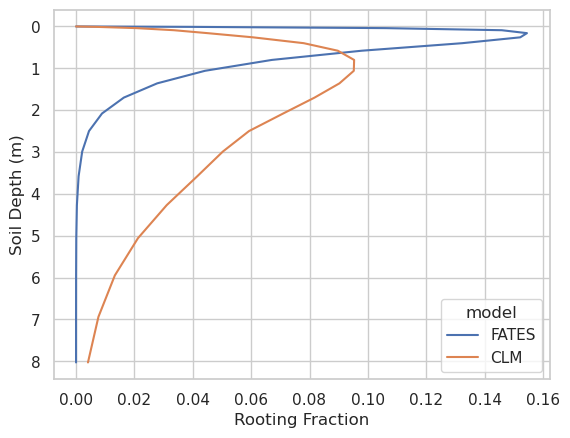

In [22]:
pft = 6
dat = clm_fates_pfts[clm_fates_pfts.clm_index == pft].copy()
clm_rootfr = calculate_clm_rootfr(z, dat['beta'].values[0])
fates_rootfr = calculate_fates_rootfr(z, dat['a'].values[0],
                                       dat['b'].values[0])

clm_pft = dat['clm_pft'].values[0]
fates_pft = dat['fates_pft'].values[0]

df = pd.DataFrame({'depth': z,
                  'FATES': fates_rootfr,
                  'CLM': clm_rootfr}).melt(id_vars='depth', var_name='model')

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots()
sns.lineplot(
    data=df.sort_values(by="depth"), 
    x="value",
    y="depth",
    hue="model",
    sort=False,
    ax=ax,
)
ax.invert_yaxis()
ax.set_ylabel('Soil Depth (m)')
ax.set_xlabel('Rooting Fraction');
plt.savefig('/glade/work/afoster/FATES_calibration/figures/oaat_figs/root_fraction_BDET.png')